# Intro to Python: Session 2: Plotting with Matplotlib

**By the end of this session you'll be able to:**
- Import a library
- Create a figure with `plt.subplots()`
- Plot data and control its appearance with keyword arguments
- Add labels, title, and legend
- Work with multiple datasets on the same axes

## Setup: Picking Up From Session 1

Run this cell to reconstruct the data we'll be plotting. It's the same concrete compression dataset from last time.

In [ ]:
import math

diameter = 4  # inches
radius   = diameter / 2
area     = math.pi * radius**2

load   = [3945.5, 8548.7, 12494.2, 14993.1, 18807.1, 21042.9, 23410.3, 24857.0]  # lbs
strain = [0.000141, 0.000282, 0.000418, 0.000514, 0.000665, 0.000761, 0.000872, 0.000927]  # in/in

stress = []
for f in load:
    stress.append(f / area)

print("Data ready.")
print("Stress (psi):", stress)

## Importing Matplotlib

Python's standard library doesn't include plotting; we `import` it from the `matplotlib` package.

The convention is to import `matplotlib.pyplot` and rename it `plt` for short. You only need to do this **once per notebook**.

In [ ]:
# These two lines are equivalent; the second is the standard convention
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

Matplotlib is a popular Python library for creating static, animated, and interactive visualizations. It provides a wide range of tools for creating various types of plots and charts, making it valuable for data visualization and scientific plotting.

**But why did we need to import that? We didn't need to import `print`!**

Python has a modular design: not all functionality is available by default. Built-in functions like `print` are always there. But more specialized functionality, like data visualization with Matplotlib, lives in external libraries. These aren't included in the Python core because they aren't needed by everyone, and loading them by default would slow down Python's startup and use more memory. Instead, you selectively import what you need.

So let's get back to our plotting problem.

## Documentation is Your Friend

Most of programming is finding the right resources to read and then sorting through to find what you need. For plotting in Python, one of the best places to go is the Matplotlib documentation itself:

[https://matplotlib.org/stable/index.html](https://matplotlib.org/stable/index.html)

The **Quick-start guide** is a good place to start to get a sense of the library as a whole.

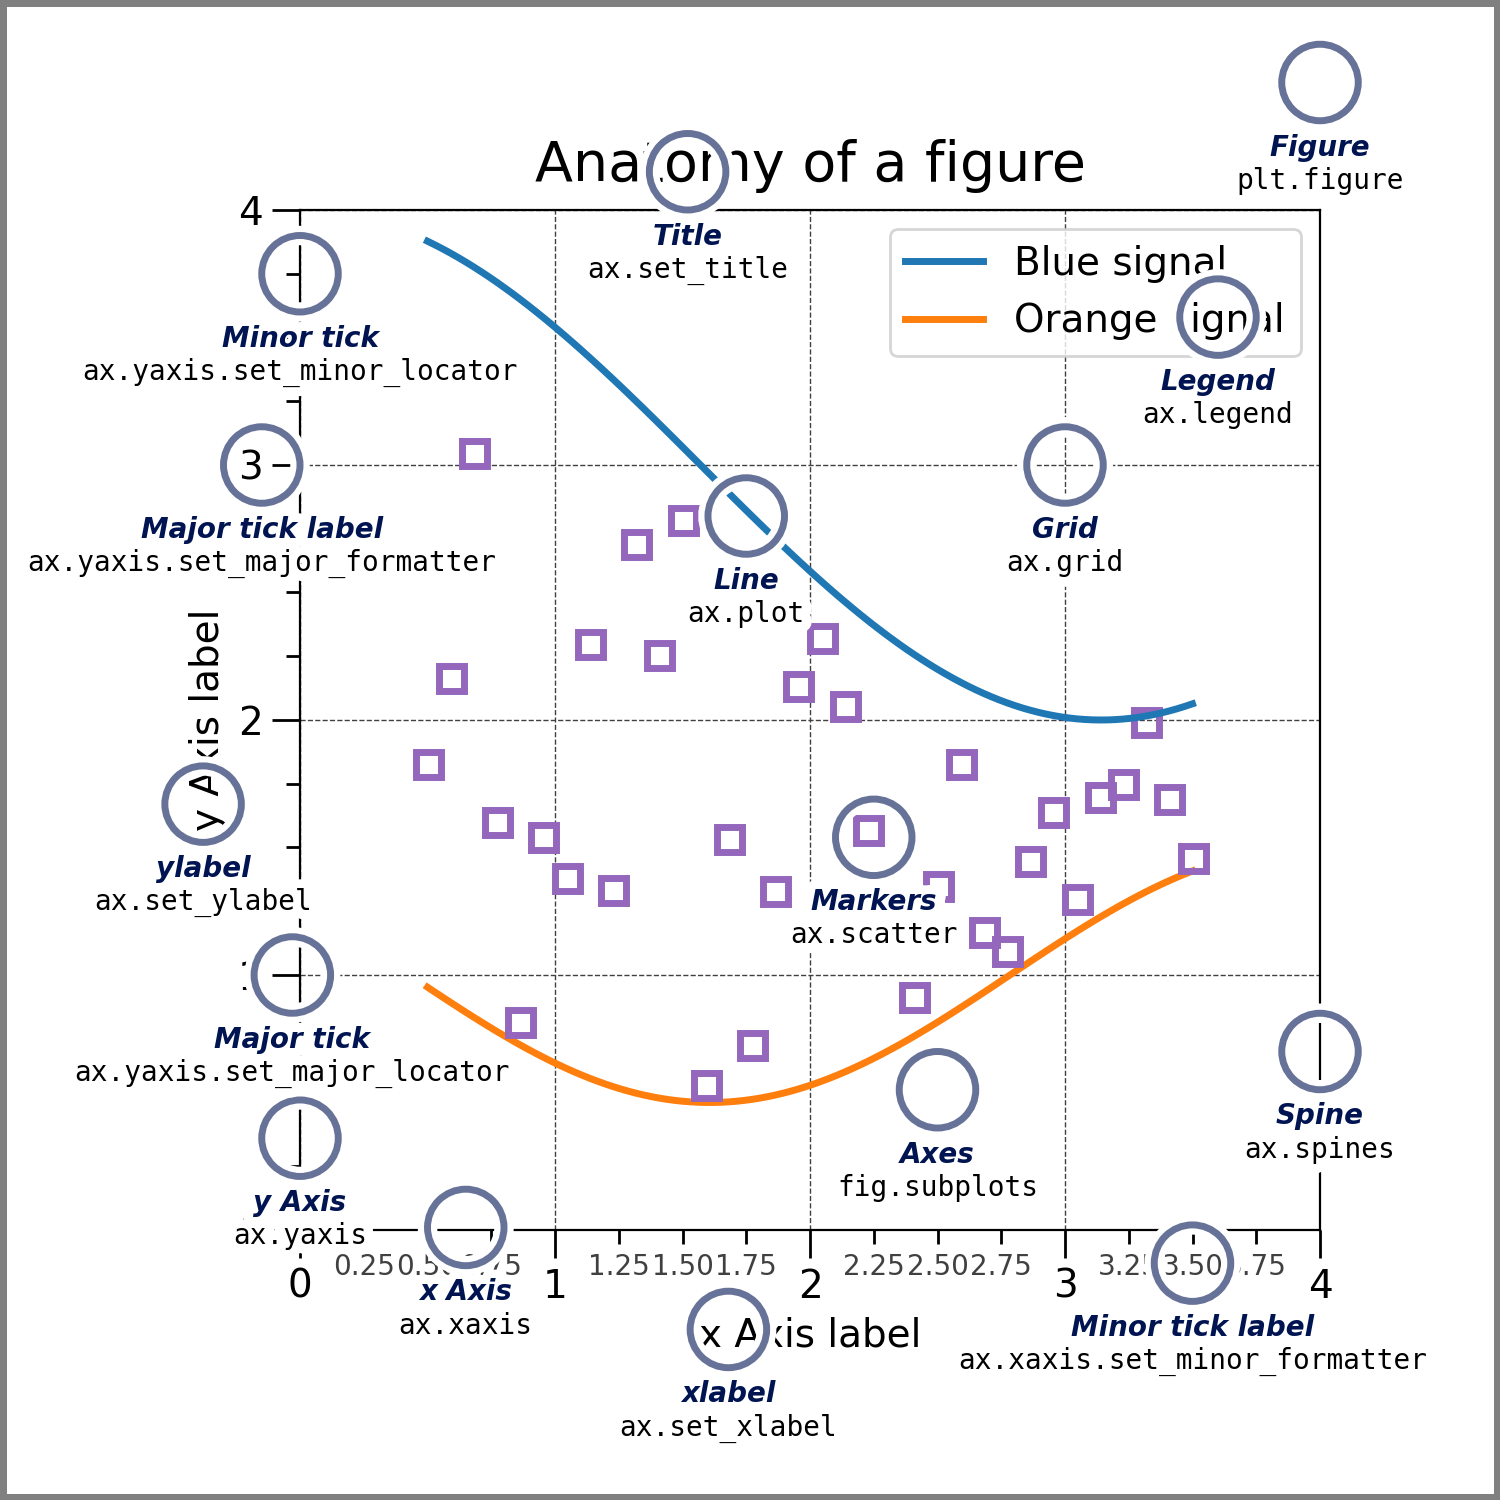

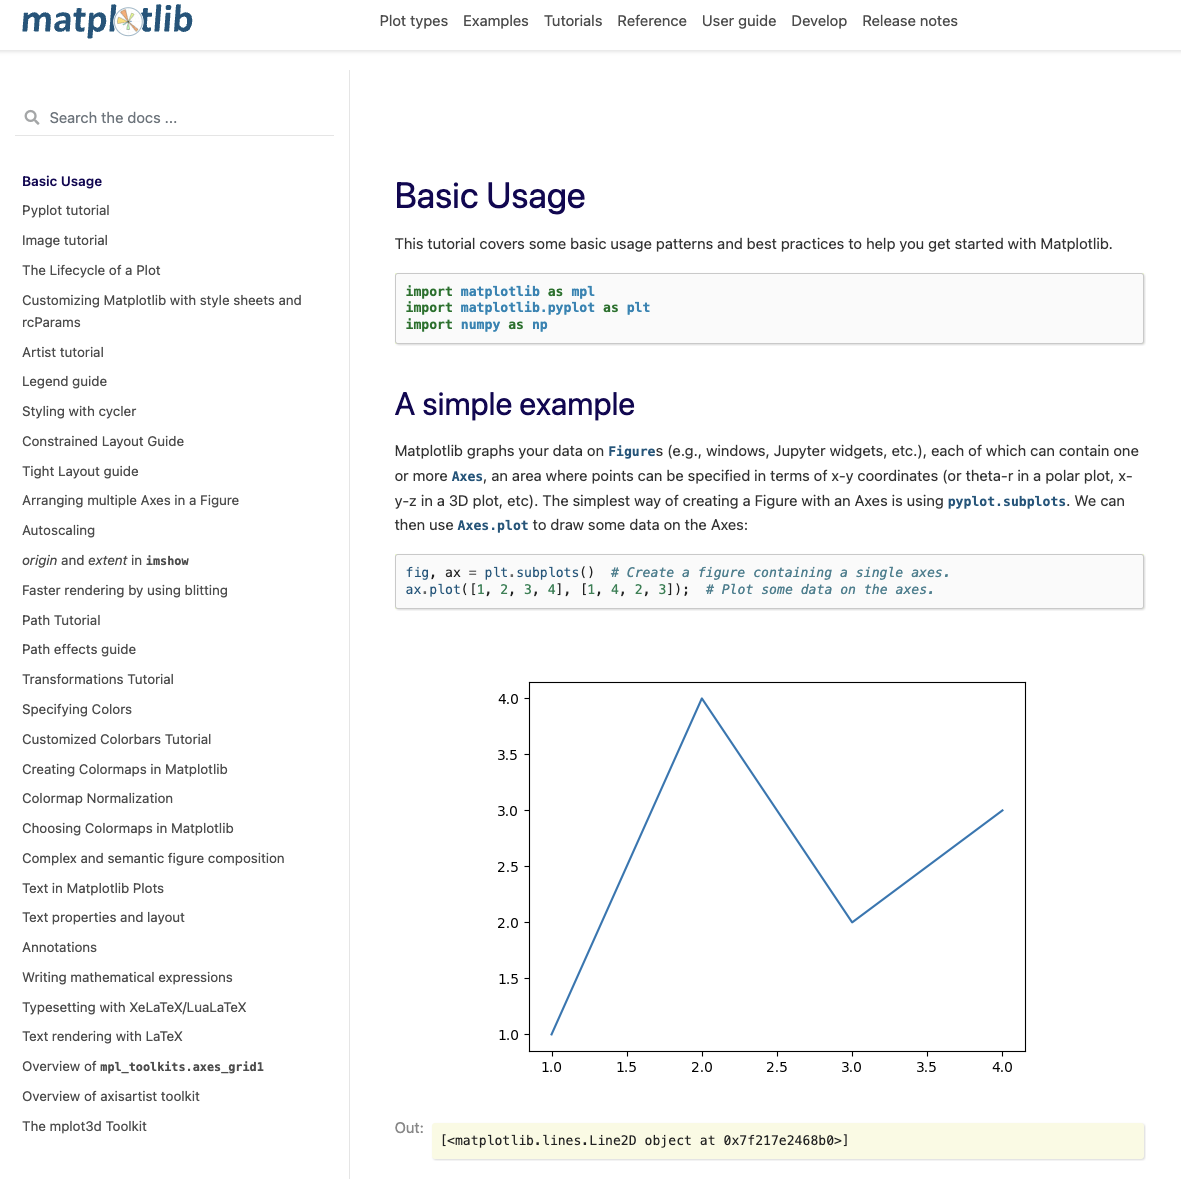

## Creating a Figure

`plt.subplots()` creates two things and returns them:
- **`fig`**: the Figure (the whole canvas)
- **`ax`**: the Axes (the plotting area inside the canvas)

We store both as variables so we can keep adding to them later.

In [ ]:
fig, ax = plt.subplots()
ax.plot(strain, stress)

`ax.plot()` draws a **connected line** by default. Let's make it more useful by adding labels and a title.

Notice the method names use `set_` on the axes object:

In [ ]:
fig, ax = plt.subplots()
ax.plot(strain, stress)
ax.set_xlabel('Strain (in/in)')
ax.set_ylabel('Stress (psi)')
ax.set_title('Concrete Compression Test')

## 🚧 Your Turn #1: Scatter Plot

For experimental data, a **scatter plot** (individual points, no line) is usually more honest than a connected line. The `ax.plot()` function has keyword arguments that control appearance.

Look at the [matplotlib docs](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html) or the hint below and modify the plot to show individual points with no connecting line.

*Hint: try `marker='.'` and `linestyle='none'`*

In [ ]:
# ADD CODE HERE
fig, ax = plt.subplots()
# modify the ax.plot() call below to be a scatter plot
ax.plot(strain, stress)
ax.set_xlabel('Strain (in/in)')
ax.set_ylabel('Stress (psi)')
ax.set_title('Concrete Compression Test')

## Coming Back to a Figure

Because `fig` and `ax` are just variable names **you choose**, you can, and should, name them something meaningful. And because they're stored as variables, you can come back and modify the same figure across multiple cells without losing your work.

Type the figure variable name on its own line to display it.

In [ ]:
# Variable names are your choice; use something meaningful
fig_concrete, ax_concrete = plt.subplots()
ax_concrete.plot(strain, stress, marker='.', linestyle='none')
ax_concrete.set_xlabel('Strain (in/in)')
ax_concrete.set_ylabel('Stress (psi)')

In [ ]:
# Come back later and add to the same figure; it remembers everything
ax_concrete.set_title('Concrete Compression Test (elastic region)')
fig_concrete

## Multiple Datasets

Call `ax.plot()` again with different data; it adds to the same axes. Use `label=` to name each dataset for the legend, then call `ax.legend()`.

In [ ]:
# A second test run on a different cylinder
load_2 = [3500.0, 8000.0, 11500.0, 14000.0, 17500.0, 19800.0, 22000.0, 23500.0]

stress_2 = []
for f in load_2:
    stress_2.append(f / area)

In [ ]:
fig, ax = plt.subplots()
ax.plot(strain, stress,   marker='.', linestyle='none', label='Test 1')
ax.plot(strain, stress_2, marker='.', linestyle='none', label='Test 2')
ax.set_xlabel('Strain (in/in)')
ax.set_ylabel('Stress (psi)')
ax.set_title('Concrete Compression: Two Tests')
ax.legend()

## 🚧 Your Turn #2: Color

Modify the plot above so **Test 1 is blue** and **Test 2 is red**.

Add the `color=` keyword argument to each `ax.plot()` call. Check the [named colors reference](https://matplotlib.org/stable/gallery/color/named_colors.html) for valid values.

In [ ]:
# ADD CODE HERE

## 🚧 Your Turn #3: Keyword Arguments Exploration

The `linestyle=` argument accepts more than just `'none'`. Try at least two other options from the [linestyle documentation](https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html) and see what they look like.

Then make a single plot with:
- Test 1 as a **dashed blue line**
- Test 2 as **red dots** (no line)

In [ ]:
# ADD CODE HERE

## 🚧 Your Turn #4: Final Plot

Create a clean, polished scatter plot of `stress` vs `strain` for **Test 1 only**:
- Individual blue data points, no connecting line
- Labeled axes with units
- Descriptive title
- No legend needed (only one dataset)

This is the same plot you'll produce from the full 20-point dataset in the Linear Regression lesson.

In [ ]:
# ADD CODE HERE

---
## 📋 Today's In-Class Assignment

**Your Turn #4 above is your in-class assignment for today. Submit it to Canvas before you leave.**

To submit:
1. Make sure your code in the cell above runs without errors (press Shift+Enter to run it)
2. Take a screenshot of your code and its output
3. Go to the module on Canvas that this lesson was part of and find today's in-class assignment, due at midnight
4. Upload your screenshot

*If you have multiple screenshots, combine them into a single PDF before uploading.*

**You only need to show that you tried; this is graded on effort, not perfection.**

---

## `ax.scatter()`: An Alternative You'll See Online

You'll encounter `ax.scatter()` in online examples and on exams. It produces the same result as `ax.plot()` with scatter-style arguments but with slightly different syntax:

```python
ax.scatter(x, y)                              # basic
ax.scatter(x, y, color='blue', marker='^')    # with options
```

| Action | `ax.plot()` style | `ax.scatter()` style |
|--------|-------------------|----------------------|
| Basic scatter | `ax.plot(x, y, marker='.', linestyle='none')` | `ax.scatter(x, y)` |
| Color | `color='blue'` | `color='blue'` |
| Marker | `marker='^'` | `marker='^'` |
| Label | `label='data'` | `label='data'` |

In this course we use `ax.plot()`, but you should recognize `ax.scatter()` when you see it.

In [ ]:
fig_scatter, ax_scatter = plt.subplots()
ax_scatter.scatter(strain, stress, color='blue', marker='.')
ax_scatter.set_xlabel('Strain (in/in)')
ax_scatter.set_ylabel('Stress (psi)')
ax_scatter.set_title('Same plot, using ax.scatter()')

This just hits the tip of the iceberg of all the interesting things you can do and the ways you can look at data with Matplotlib. Explore the gallery to see what's possible:

[https://matplotlib.org/stable/gallery/index.html](https://matplotlib.org/stable/gallery/index.html)

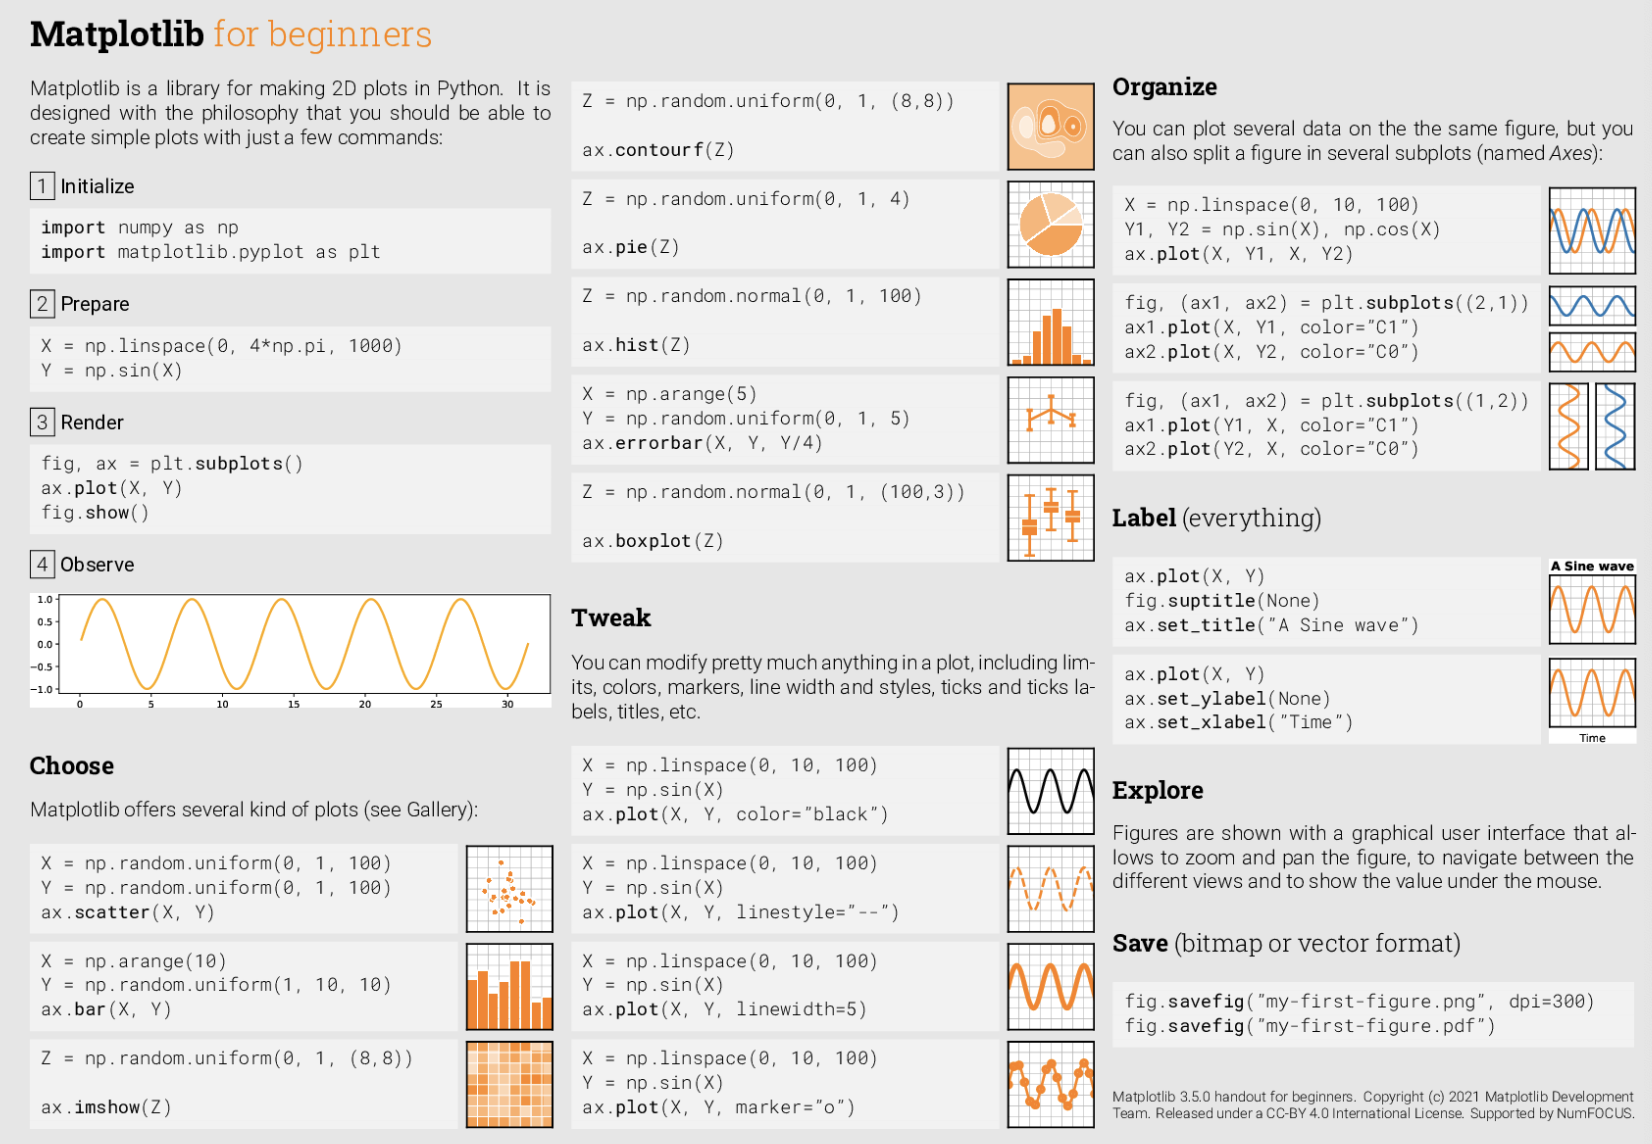

## Up Next: Linear Regression

In the next lesson we'll load the **full 20-point** concrete compression dataset and:
1. Convert the force data to stress using NumPy arrays (faster than for loops for large data)
2. Fit a line to the elastic region using `scipy.stats.linregress`
3. Calculate the **modulus of elasticity**, a key structural material property

Every skill from these two sessions appears in that lesson.